In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Data Sources

**Included:** `CRMLSSold*.csv` — 6 monthly extracts (2025-12 through 2026-05), 112,697 rows before filtering.
**Excluded:** `CRMLSListing*.csv`.

| | Sold files | Listing files |
|---|---|---|
| `ClosePrice` coverage | 100% | ~25% (sample: 8,919 / 35,959 non-null) |
| Record type | Completed transactions only | Mix of Active, Pending, ActiveUnderContract, ComingSoon, Closed |
| `ListPrice` / `OriginalListPrice` / `DaysOnMarket` | Included | Included |
| Schema | Clean | 10 duplicate column names |

`ClosePrice` is the target variable for this analysis, so the dataset is scoped to completed transactions (Sold files). The Sold files already carry `ListPrice` and `DaysOnMarket`, so no coverage is lost by omitting Listing files, and no deduplication is required between sources. Listing data would be revisited in a future phase for active-inventory valuation, which is outside the scope of this deliverable.

In [40]:
# Combined the latest 6-month datasets

files = [
    "data/CRMLSSold202512.csv",
    "data/CRMLSSold202601.csv",
    "data/CRMLSSold202602.csv",
    "data/CRMLSSold202603.csv",
    "data/CRMLSSold202604.csv",
    "data/CRMLSSold202605.csv",
]

df = pd.concat(
    [pd.read_csv(file, low_memory=False) for file in files], 
    ignore_index=True)

print("Original dataset shape:", df.shape)

Original dataset shape: (112697, 80)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112697 entries, 0 to 112696
Data columns (total 80 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 106295 non-null  object 
 1   ListAgentAOR                  112654 non-null  object 
 2   Flooring                      65526 non-null   object 
 3   ViewYN                        101457 non-null  object 
 4   WaterfrontYN                  84 non-null      object 
 5   BasementYN                    1815 non-null    object 
 6   PoolPrivateYN                 100228 non-null  object 
 7   OriginalListPrice             112331 non-null  float64
 8   ListingKey                    112697 non-null  int64  
 9   ListAgentEmail                36920 non-null   object 
 10  CloseDate                     112697 non-null  object 
 11  ClosePrice                    112695 non-null  float64
 12  ListAgentFirstName            112239 non-nul

In [42]:
# Convert CloseDate to datetime

df['CloseDate'] = pd.to_datetime(
    df['CloseDate'],
    errors='coerce'
)

print('Earliest close date:', df['CloseDate'].min())
print('Latest close date:', df['CloseDate'].max())
print(
    'Number of months:',
    df['CloseDate'].dt.to_period('M').nunique()
)

Earliest close date: 2025-12-01 00:00:00
Latest close date: 2026-05-31 00:00:00
Number of months: 6


In [43]:
# Check the number of records from each month
df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

monthly_counts = (
    df['CloseMonth']
    .value_counts()
    .sort_index()
)

monthly_counts

CloseMonth
2025-12    20538
2026-01    16487
2026-02    19060
2026-03     8000
2026-04    24397
2026-05    24215
Freq: M, Name: count, dtype: int64

In [44]:
# Filter to Residential Single Family
df_filtered = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print('Filtered dataset shape:', df_filtered.shape)

Filtered dataset shape: (55582, 81)


In [45]:
# to confirm the filter
print(df_filtered['PropertyType'].value_counts())
print(df_filtered['PropertySubType'].value_counts())

PropertyType
Residential    55582
Name: count, dtype: int64
PropertySubType
SingleFamilyResidence    55582
Name: count, dtype: int64


In [46]:
# Preview the filtered dataset
df_filtered.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,CloseMonth
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN,NaN,NaN,2025-12
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,False,3.0,NaN,91364,NaN,34745.0,NaN,NaN,NaN,2025-12
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,False,2.0,Other,95121,NaN,6600.0,NaN,NaN,NaN,2025-12
7,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN,NaN,NaN,2025-12
9,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,False,2.0,Other,95128,NaN,9222.0,NaN,NaN,NaN,2025-12


In [47]:
# Only select the required EDA columns
eda_cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

eda_df = df_filtered[eda_cols].copy()
eda_df.head()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
0,1998000.0,2045.0,4.0,2.0,10080.0
2,2214421.0,3050.0,4.0,4.0,34745.0
3,1200000.0,1594.0,4.0,2.0,6600.0
7,3100000.0,2700.0,5.0,3.0,8262.0
9,2900000.0,2948.0,5.0,4.0,9222.0


In [48]:
# Check data types
eda_df.dtypes

ClosePrice               float64
LivingArea               float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
LotSizeSquareFeet        float64
dtype: object

In [49]:
# Summary Statistics
eda_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ClosePrice,55582.0,1.278791e+06,2.453080e+06,1.75,625000.0,900000.0,1439875.0,4.720000e+08
LivingArea,55552.0,2.051614e+03,1.029032e+03,0.00,1384.0,1824.0,2450.0,2.331400e+04
BedroomsTotal,55582.0,3.497391e+00,9.639993e-01,0.00,3.0,3.0,4.0,2.200000e+01
BathroomsTotalInteger,55581.0,2.641154e+00,1.132685e+00,0.00,2.0,2.0,3.0,2.200000e+01
LotSizeSquareFeet,54549.0,3.419258e+05,1.679085e+07,0.00,5663.0,7245.0,10454.0,1.897474e+09


In [50]:
# Check missing values

missing_summary = pd.DataFrame({
    "MissingCount": eda_df.isna().sum(),
    "MissingPercent": eda_df.isna().mean() * 100
})

missing_summary

,MissingCount,MissingPercent
ClosePrice,0,0.000000
LivingArea,30,0.053974
BedroomsTotal,0,0.000000
BathroomsTotalInteger,1,0.001799
LotSizeSquareFeet,1033,1.858515


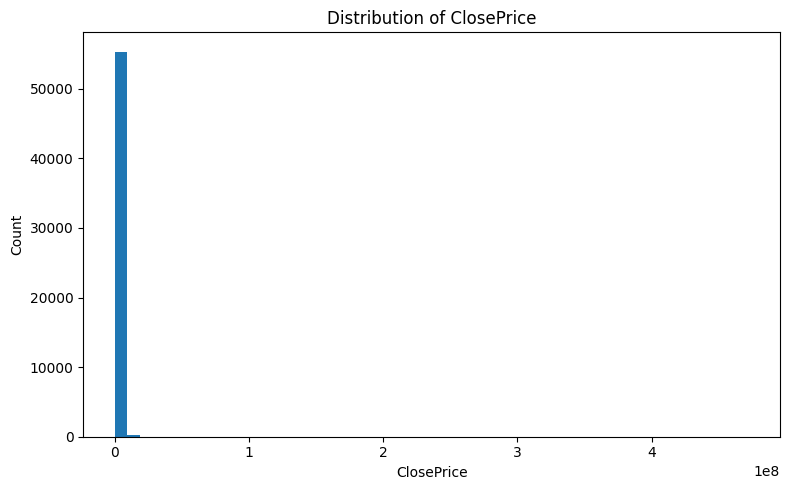

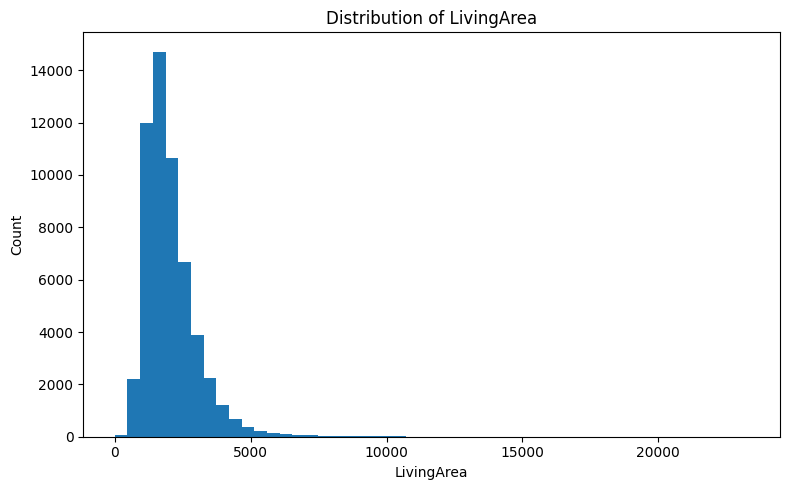

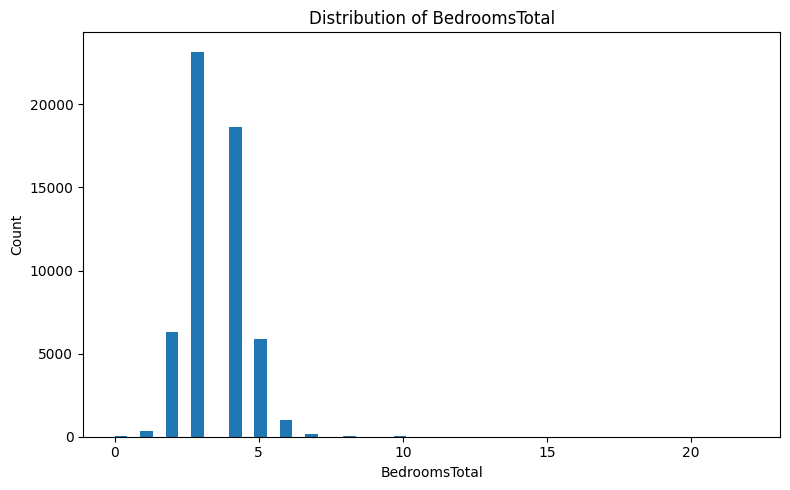

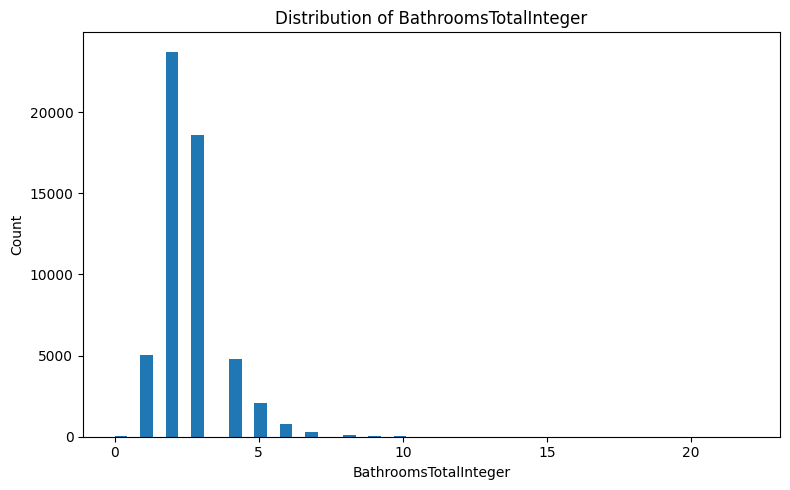

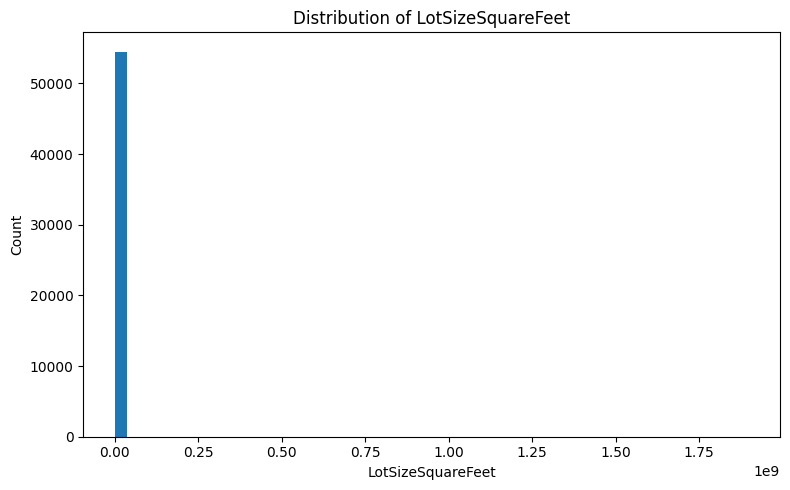

In [51]:
# Basic histograms

for col in eda_cols:
    plt.figure(figsize=(8, 5))

    plt.hist(
        eda_df[col].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [52]:
# Check for zero and negative values
invalid_value_summary = pd.DataFrame({
    "ZeroValues": (eda_df == 0).sum(),
    "NegativeValues": (eda_df < 0).sum()
})

invalid_value_summary

,ZeroValues,NegativeValues
ClosePrice,0,0
LivingArea,18,0
BedroomsTotal,28,0
BathroomsTotalInteger,23,0
LotSizeSquareFeet,42,0


In [54]:
# Remove zero values from the main EDA features for clearer plots
eda_clean = eda_df[
    (eda_df["ClosePrice"] > 0) &
    (eda_df["LivingArea"] > 0) &
    (eda_df["BedroomsTotal"] > 0) &
    (eda_df["BathroomsTotalInteger"] > 0) &
    (eda_df["LotSizeSquareFeet"] > 0)
].copy()

print("Original number of rows:", len(eda_df))
print("Rows after removing zero values:", len(eda_clean))
print("Rows removed:", len(eda_df) - len(eda_clean))

Original number of rows: 55582
Rows after removing zero values: 54426
Rows removed: 1156


The dataset contained a small number of zero values in `LivingArea`, `BedroomsTotal`, `BathroomsTotalInteger`, and `LotSizeSquareFeet`. No negative values were found. Since zero values may represent missing or incorrectly recorded property information, these observations were excluded from selected EDA visualizations. The original dataset was retained, and permanent preprocessing decisions will be made during the data-cleaning stage.

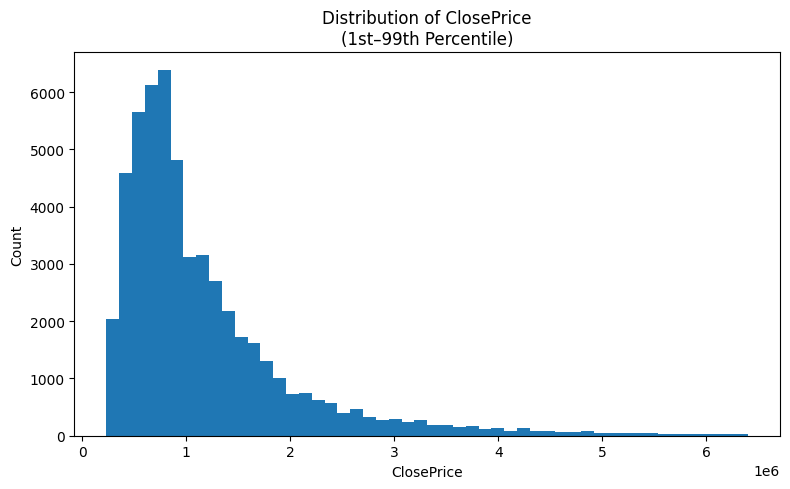

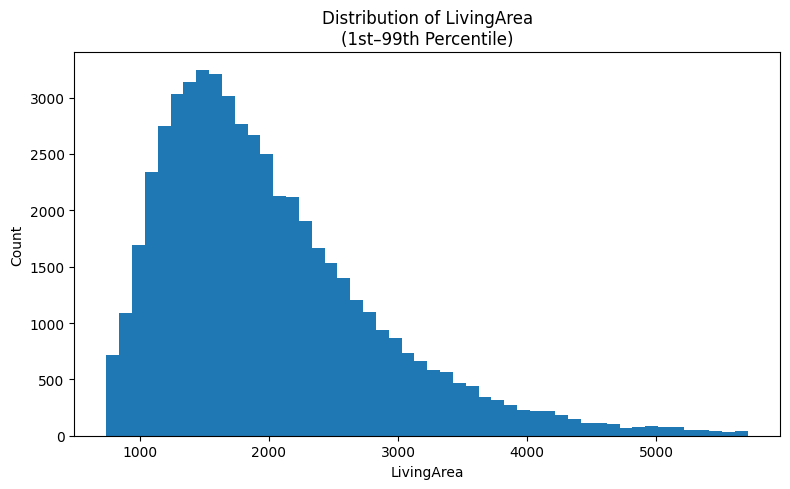

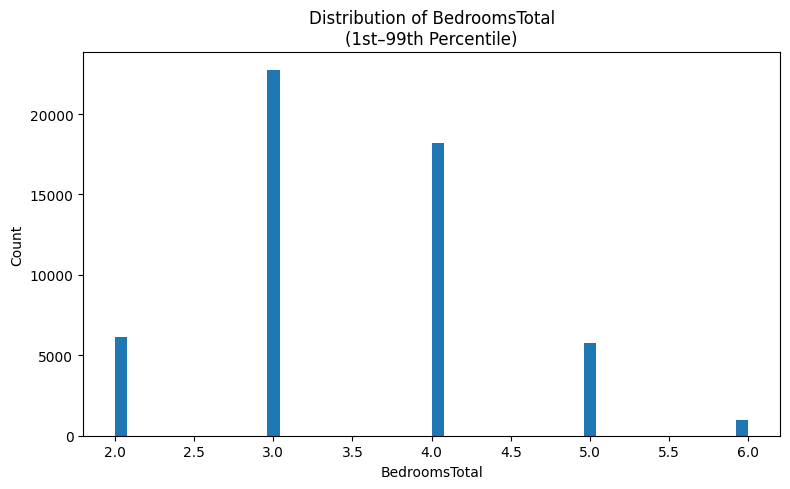

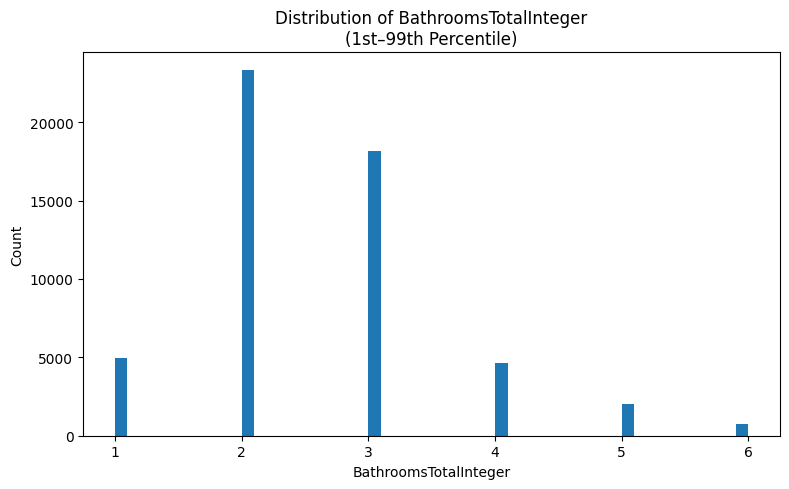

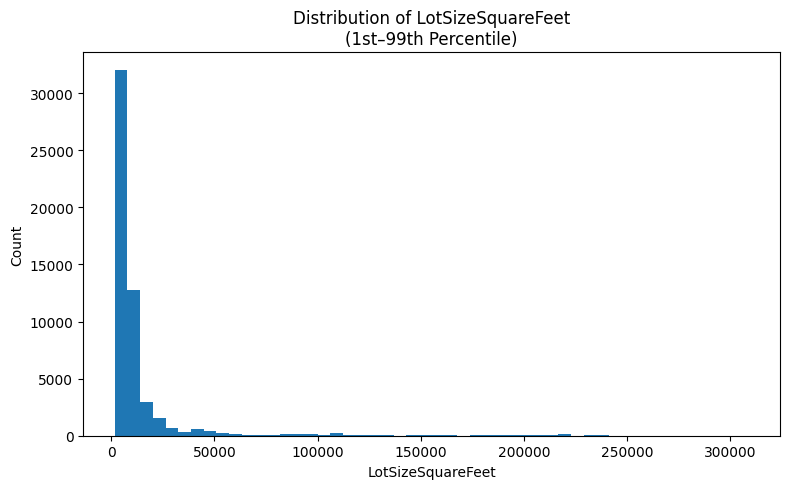

In [55]:
# Plot histograms using the 1st-99th percentile range

for col in eda_cols:
    lower = eda_clean[col].quantile(0.01)
    upper = eda_clean[col].quantile(0.99)

    plot_data = eda_clean[
        eda_clean[col].between(lower, upper)
    ]

    plt.figure(figsize=(8, 5))

    plt.hist(
        plot_data[col],
        bins=50
    )

    plt.title(
        f"Distribution of {col}\n"
        "(1st–99th Percentile)"
    )

    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

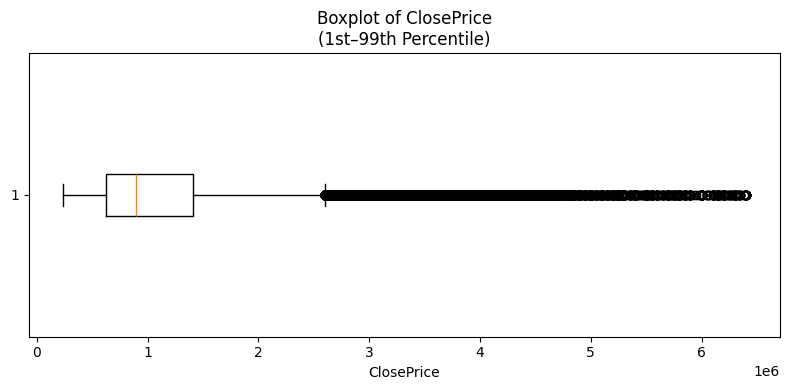

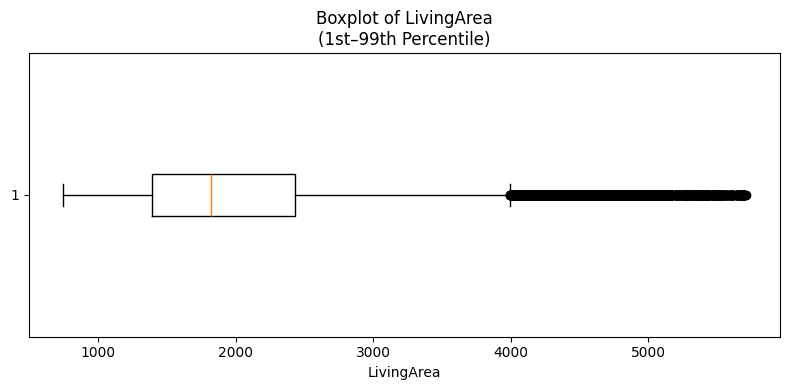

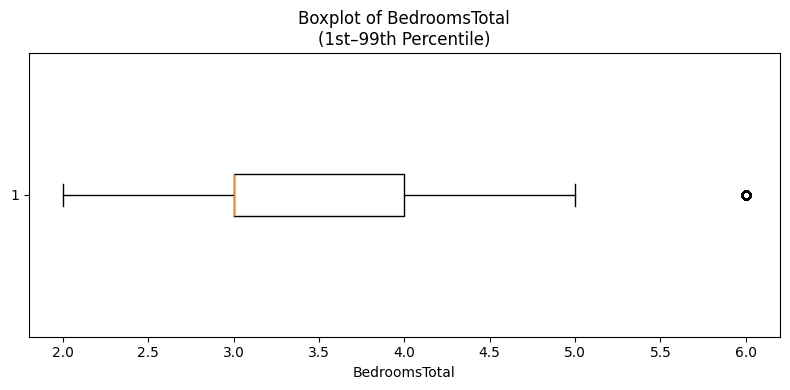

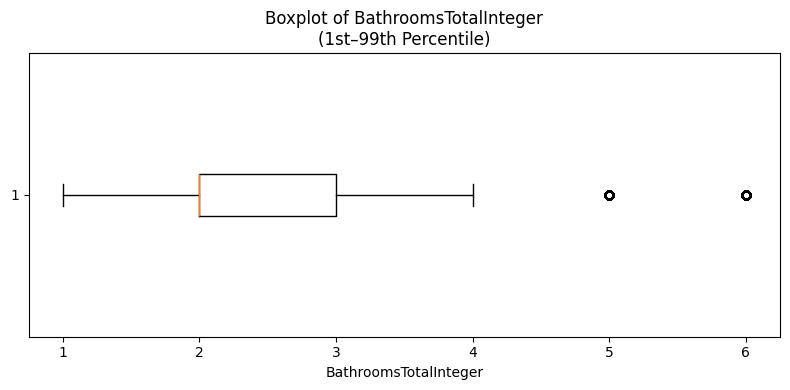

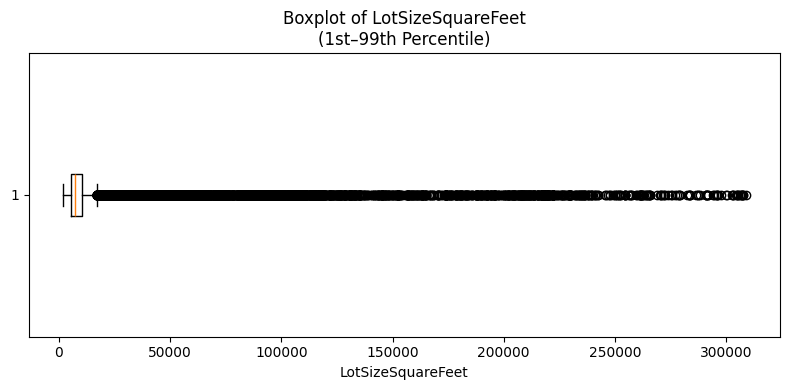

In [57]:
# Boxplots for outlier checking
# Using the percentile-filtered values to make the boxplots more readable

for col in eda_cols:
    lower = eda_clean[col].quantile(0.01)
    upper = eda_clean[col].quantile(0.99)

    plot_data = eda_clean.loc[
        eda_clean[col].between(lower, upper),
        col
    ]

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        plot_data.dropna(),
        vert=False
    )

    plt.title(
        f"Boxplot of {col}\n"
        "(1st–99th Percentile)"
    )

    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [58]:
# Correlation Matrix

correlation_matrix = eda_clean.corr()

correlation_matrix

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
ClosePrice,1.000000,0.360182,0.188310,0.321427,-0.001435
LivingArea,0.360182,1.000000,0.658464,0.852769,0.007011
BedroomsTotal,0.188310,0.658464,1.000000,0.656838,0.006607
BathroomsTotalInteger,0.321427,0.852769,0.656838,1.000000,0.004374
LotSizeSquareFeet,-0.001435,0.007011,0.006607,0.004374,1.000000


In [60]:
# Show the correlations with ClosePrice
correlation_matrix["ClosePrice"].sort_values(
    ascending=False
)

ClosePrice               1.000000
LivingArea               0.360182
BathroomsTotalInteger    0.321427
BedroomsTotal            0.188310
LotSizeSquareFeet       -0.001435
Name: ClosePrice, dtype: float64

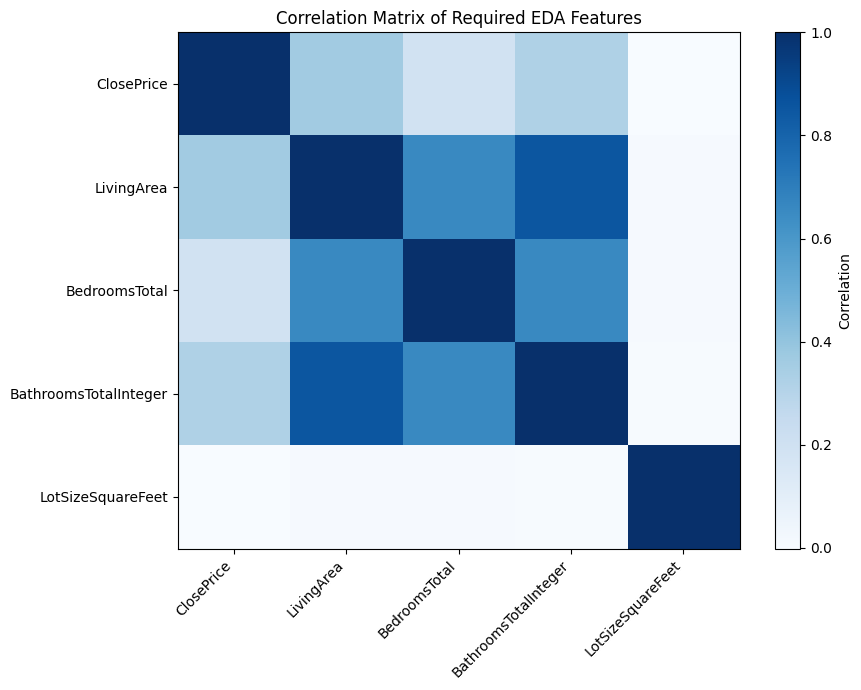

In [69]:
# Plot the correlation matrix
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    cmap="Blues",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Required EDA Features")
plt.tight_layout()
plt.show()

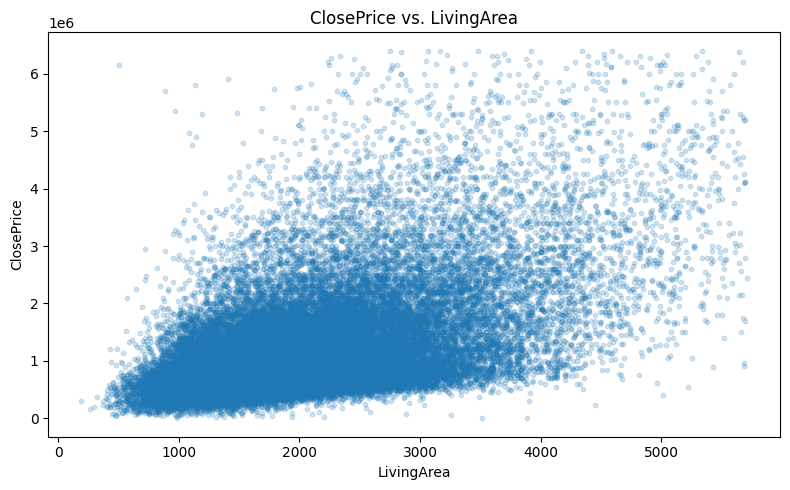

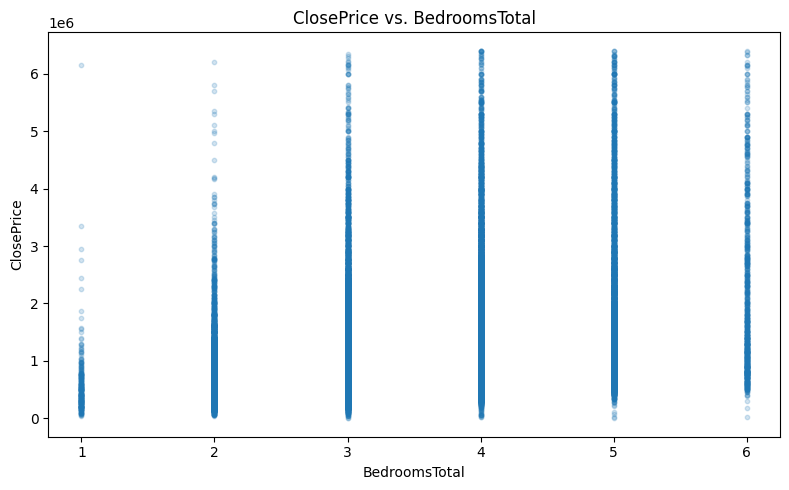

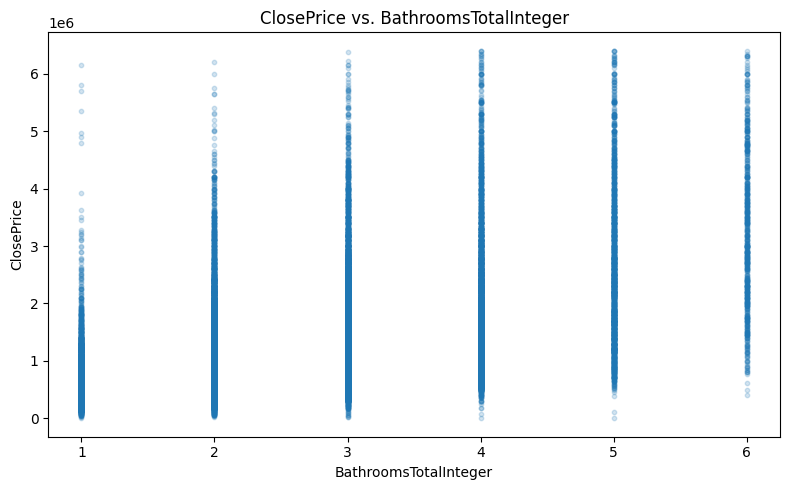

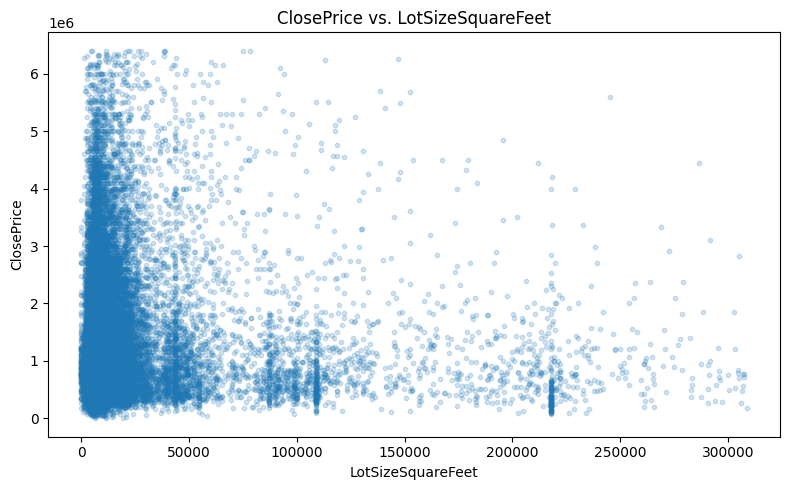

In [62]:
# Scatter plots against ClosePrice
predictor_cols = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

for col in predictor_cols:
    feature_upper = eda_clean[col].quantile(0.99)
    price_upper = eda_clean["ClosePrice"].quantile(0.99)

    plot_data = eda_clean[
        (eda_clean[col] <= feature_upper) &
        (eda_clean["ClosePrice"] <= price_upper)
    ]

    plt.figure(figsize=(8, 5))

    plt.scatter(
        plot_data[col],
        plot_data["ClosePrice"],
        alpha=0.2,
        s=10
    )

    plt.title(f"ClosePrice vs. {col}")
    plt.xlabel(col)
    plt.ylabel("ClosePrice")
    plt.tight_layout()
    plt.show()

The plots for bedrooms and bathrooms appear as vertical groups because those variables contain whole-number values.

In [63]:
# Monthly housing-market summary
monthly_summary = (
    df_filtered
    .dropna(subset=["CloseDate"])
    .groupby("CloseMonth")
    .agg(
        NumberOfSales=("ClosePrice", "count"),
        MedianClosePrice=("ClosePrice", "median"),
        AverageClosePrice=("ClosePrice", "mean"),
        MedianLivingArea=("LivingArea", "median")
    )
)

monthly_summary

,NumberOfSales,MedianClosePrice,AverageClosePrice,MedianLivingArea
CloseMonth,,,,
2025-12,10455,860000.0,1.195244e+06,1804.0
2026-01,7490,851691.5,1.280369e+06,1821.0
2026-02,8965,875000.0,1.237592e+06,1823.0
2026-03,3697,1100000.0,1.450833e+06,1762.0
2026-04,12522,915000.0,1.309401e+06,1834.0
2026-05,12453,927000.0,1.295787e+06,1855.0


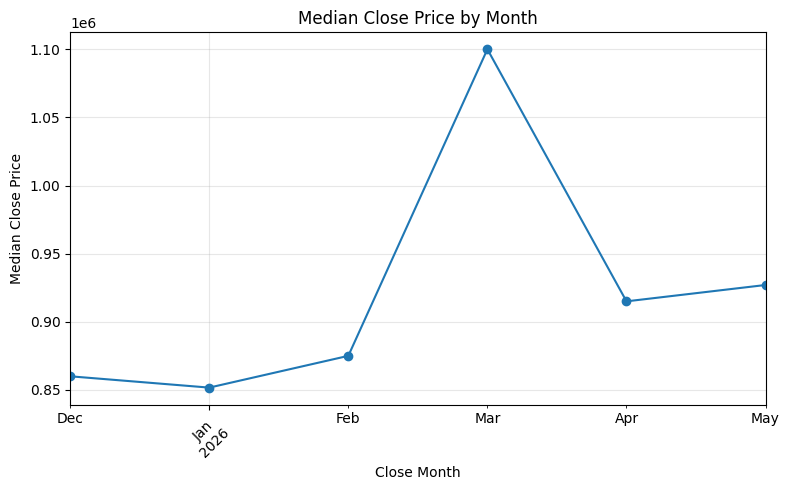

In [64]:
# Median close price by month
monthly_summary["MedianClosePrice"].plot(
    figsize=(8, 5),
    marker="o"
)

plt.title("Median Close Price by Month")
plt.xlabel("Close Month")
plt.ylabel("Median Close Price")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

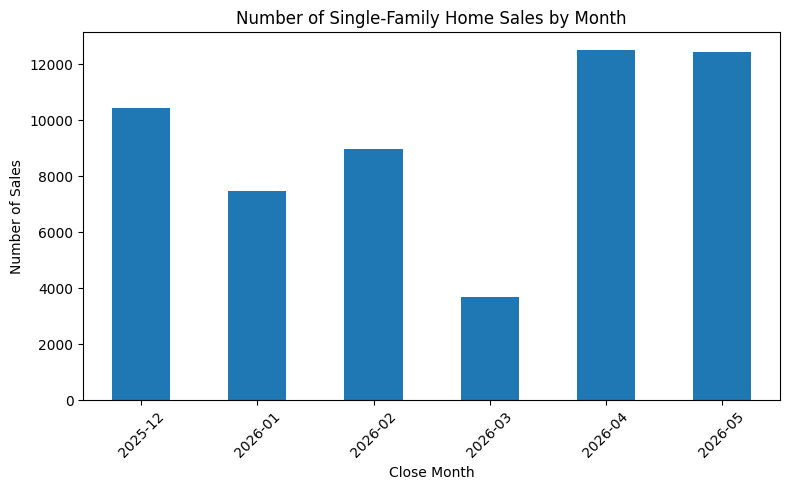

In [65]:
# Number of sales by month
monthly_summary["NumberOfSales"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Single-Family Home Sales by Month")
plt.xlabel("Close Month")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()